# Prepare input data for evapotranspiration modelling

In this notebook, data required to run evapotranspiration modelling, which was collected in the previous notebook, is pre-processed to be used as into to TSEB evapotranspiration model.

This notebook can be run on the [Copernicus Dataspace Jupyterhub](https://jupyterhub.dataspace.copernicus.eu) in which case data downloads are downloaded since both the data and the execution environment are on CDSE. 

**Note** You should select on of the kernels with GDAL installed, eg. "Geo science".

First we check that Sen-ET Toolbox is installed (and install it if necessary) and then we import all the necessary packages.

In [1]:
try:
    import senet_toolbox
except ModuleNotFoundError:
    !pip install senet_toolbox@git+https://github.com/DHI/Sen-ET-OpenEO-toolbox.git

In [2]:
from pathlib import Path
from datetime import datetime
import re

from senet_toolbox import date_selector, visualization, raster_utils, read_area_date_info, load_lut
from senet_toolbox.workflows.decision_tree_sharpener import sharpen_lst
from senet_toolbox.workflows.prepare_ancillary_data import prepare_dem, prepare_lut_maps
from senet_toolbox.workflows.meteo_preprocessing import get_meteo_data
from senet_toolbox.workflows.biophysical_processing import biopar_biophysical_params

## 1. Select Area of Interest
To keep the data organised, and make processing of timeseries easier, the input and output data is kept in Area of Interest (AOI) folders. All data within an AOI folder has the same extent and grid. 

In the cell below, select the data location and AOI name which was set in input data collection notebook. It will also pick the last date which was processed by that notebook. If you would like to work with a different date then use the second cell to list the dates within the AOI for which input data was collected, select the one you want to work with from the drop down list and run the third cell to save your choice. 

In [3]:
data_dir = "./mystorage/"
aoi_name = "botswana2"
aoi_data_dir = Path(data_dir) / aoi_name
date, bbox = read_area_date_info(dir=aoi_data_dir)
date = str(date)
date_data_dir = aoi_data_dir / date.replace("-", "")
s2_path = date_data_dir / f"s2_{date_data_dir.name}_data.nc"
worldcover_path = aoi_data_dir / "WorldCover2021.tif"
print(date)

2023-05-06


In [4]:
# Run this and next cells if you would like to work with a different date
date_selection = date_selector.get_collected_dates(
    aoi_data_dir = Path(data_dir) / aoi_name
)

Dropdown(description='Pick a Date:', options=(('2023-05-05', '2023-05-05'),), value='2023-05-05')

In [5]:
date = date_selection.value
date_data_dir = aoi_data_dir / date.replace("-", "")
s2_path = date_data_dir / f"s2_{date_data_dir.name}_data.nc"
worldcover_path = aoi_data_dir / "WorldCover2021.tif"

## 2. Prepare static input data

The input data derived from digital elevation model (DEM) and from the landcover map do not change between dates so this only needs to be done once when setting up a new AOI.

**Note:** By default the static parameters are set based on Worldcover landcover map and the [default look-up-table](https://github.com/DHI/Sen-ET-OpenEO-toolbox/blob/main/senet_toolbox/static_data/WorldCover10m_2020_LUT.csv). You can alo specify paths to your custom landcover maps and look-up-tables (e.g. covering specific crops). The columns of the custom look-up-table should be the same as for the default ones and the rows should match the classes present in the landcover map.

In [ ]:
prepare_dem(aoi_data_dir / "cdem.tif")

In [7]:
lut = load_lut()
prepare_lut_maps(worldcover_path, lut)

2026-03-11 15:57:40,182 [INFO] Saved raster: mystorage/botswana/W_C.tif
2026-03-11 15:57:40,183 [INFO] Saved veg_height_width_ratio to mystorage/botswana/W_C.tif
2026-03-11 15:57:40,545 [INFO] Saved raster: mystorage/botswana/LEAF_WIDTH.tif
2026-03-11 15:57:40,546 [INFO] Saved veg_leaf_width to mystorage/botswana/LEAF_WIDTH.tif
2026-03-11 15:57:40,801 [INFO] Saved raster: mystorage/botswana/F_C.tif
2026-03-11 15:57:40,801 [INFO] Saved veg_fractional_cover to mystorage/botswana/F_C.tif
2026-03-11 15:57:41,137 [INFO] Saved raster: mystorage/botswana/IGBP.tif
2026-03-11 15:57:41,138 [INFO] Saved igbp_classification to mystorage/botswana/IGBP.tif
2026-03-11 15:57:41,470 [INFO] Saved raster: mystorage/botswana/X_LAD.tif
2026-03-11 15:57:41,470 [INFO] Saved veg_inclination_distribution to mystorage/botswana/X_LAD.tif


## 5. Biophysical processing of Sentinel-2 data

Many of the Sentinel-2 based biophysical parameters were already collected during the previous notebook. Here they are saved as individual GeoTiff files and used to derive the remaining biophysical parameters, such as fraction of vegetation which is green, canopy height or reflectance of the canopy. 

In [8]:
biopar_biophysical_params(s2_path, worldcover_path) 

2026-03-11 15:57:48,744 [INFO] Saved SCL to mystorage/botswana/20230509/20230509_SCL.tif
2026-03-11 15:57:48,824 [INFO] Saved sunZenithAngles to mystorage/botswana/20230509/20230509_SZA.tif
2026-03-11 15:57:49,242 [INFO] Saved LAI to mystorage/botswana/20230509/20230509_LAI.tif
2026-03-11 15:57:49,609 [INFO] Saved CCC to mystorage/botswana/20230509/20230509_CCC.tif
2026-03-11 15:57:49,979 [INFO] Saved CWC to mystorage/botswana/20230509/20230509_CWC.tif
2026-03-11 15:57:50,346 [INFO] Saved FAPAR to mystorage/botswana/20230509/20230509_FAPAR.tif
2026-03-11 15:57:51,690 [INFO] Saved raster: mystorage/botswana/20230509/20230509_F_G.tif
2026-03-11 15:57:51,692 [INFO] Saved frac_green to mystorage/botswana/20230509/20230509_F_G.tif
2026-03-11 15:57:52,536 [INFO] Saved raster: mystorage/botswana/20230509/20230509_H_C.tif
2026-03-11 15:57:52,537 [INFO] Saved H_C to mystorage/botswana/20230509/20230509_H_C.tif
2026-03-11 15:57:53,092 [INFO] Saved raster: mystorage/botswana/20230509/20230509_RHO

PosixPath('mystorage/botswana/20230509')

## 3. Sharpen Sentinel-3 Land Surface Temperature

Sentinel-3 Lands Surace Temperature (LST) is acquired with around 1 km spatial resolution. In this step, data fusion with high-resolution Sentinel-2 reflectance, DEM and DEM-based illumination conditions is performed to derive a high-resolution representation of the LST. 

**Note:** the `n_jobs` parameter is set to 2 to speed up the processing. However, for larger AOIs this can lead to too much memory consumption and the notebook crashing. In this case, set this parameter to 1.

In [9]:
s2_refl_file = list(date_data_dir.glob("*_REFL.tif"))[0]
dem_path = aoi_data_dir / "cdem.tif"
for lst_file in date_data_dir.glob("*_LST.tif"):
    datetime_utc = datetime.strptime(re.search(r"_(\d{8}T\d{6})_", lst_file.stem).group(1), "%Y%m%dT%H%M%S")
    mask_file = Path(str(lst_file).replace("_LST.tif", "_mask.tif"))
    output_file = Path(str(lst_file).replace("_LST.tif", "_LST_sharpened.tif"))

    sharpened_data = sharpen_lst(
        high_res_optical_path=s2_refl_file,
        high_res_dem_path=dem_path,
        low_res_lst=lst_file,
        low_res_lst_mask=mask_file,
        mask_values=[1],
        datetime_utc=datetime_utc, 
        cv_homogeneity_threshold=0,
        moving_window_size=20,
        disaggregating_temperature=True,
        n_jobs=2,
        n_estimators=30,
        max_samples=0.8,
        max_features=0.8,
        output_path=output_file
    )

# Resample VZA to Sentinel-2 grid
for vza_file in date_data_dir.glob("*_VZA.tif"):
    raster_utils.resample_to_template(vza_file, vza_file, s2_refl_file)

2026-03-11 15:57:56,935 [INFO] Saved raster: mystorage/botswana/20230509/cos_theta_20230509T073600.tif


Homogeneity CV threshold: 0.15
Number of training elements for is 576 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.13
Number of training elements for is 720 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.12
Number of training elements for is 312 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.14
Number of training elements for is 720 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.13
Number of training elements for is 900 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.12
Number of training elements for is 390 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.14
Number of training elements for is 360 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.14
Number of training elements for is 450 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.14
N

/home/mlla/miniconda3/envs/gdal_env/lib/python3.11/site-packages/pyDMS/pyDMS.py:506: RuntimeWarning: invalid value encountered in multiply
  outFullData = np.empty((ysize, xsize))*np.nan


0
1
2
3
4
5
6
7
8


/home/mlla/miniconda3/envs/gdal_env/lib/python3.11/site-packages/pyDMS/pyDMS.py:647: RuntimeWarning: Mean of empty slice
  print("LR residual bias: "+str(np.nanmean(residual_LR)))
/home/mlla/miniconda3/envs/gdal_env/lib/python3.11/site-packages/pyDMS/pyDMS.py:648: RuntimeWarning: Mean of empty slice
  print("LR residual RMSD: "+str(np.nanmean(residual_LR**2)**0.5))


LR residual bias: nan
LR residual RMSD: nan
Saving output...


2026-03-11 16:01:17,333 [INFO] Downscaled image saved to mystorage/botswana/20230509/s3_20230509T073600_LST_sharpened.tif
2026-03-11 16:01:17,337 [INFO] Starting resample_to_template...


Saved mystorage/botswana/20230509/s3_20230509T073600_LST_sharpened.tif


2026-03-11 16:01:17,774 [INFO] Processing completed successfully.


#### Visualize the sharpened LST

/home/mlla/miniconda3/envs/gdal_env/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(



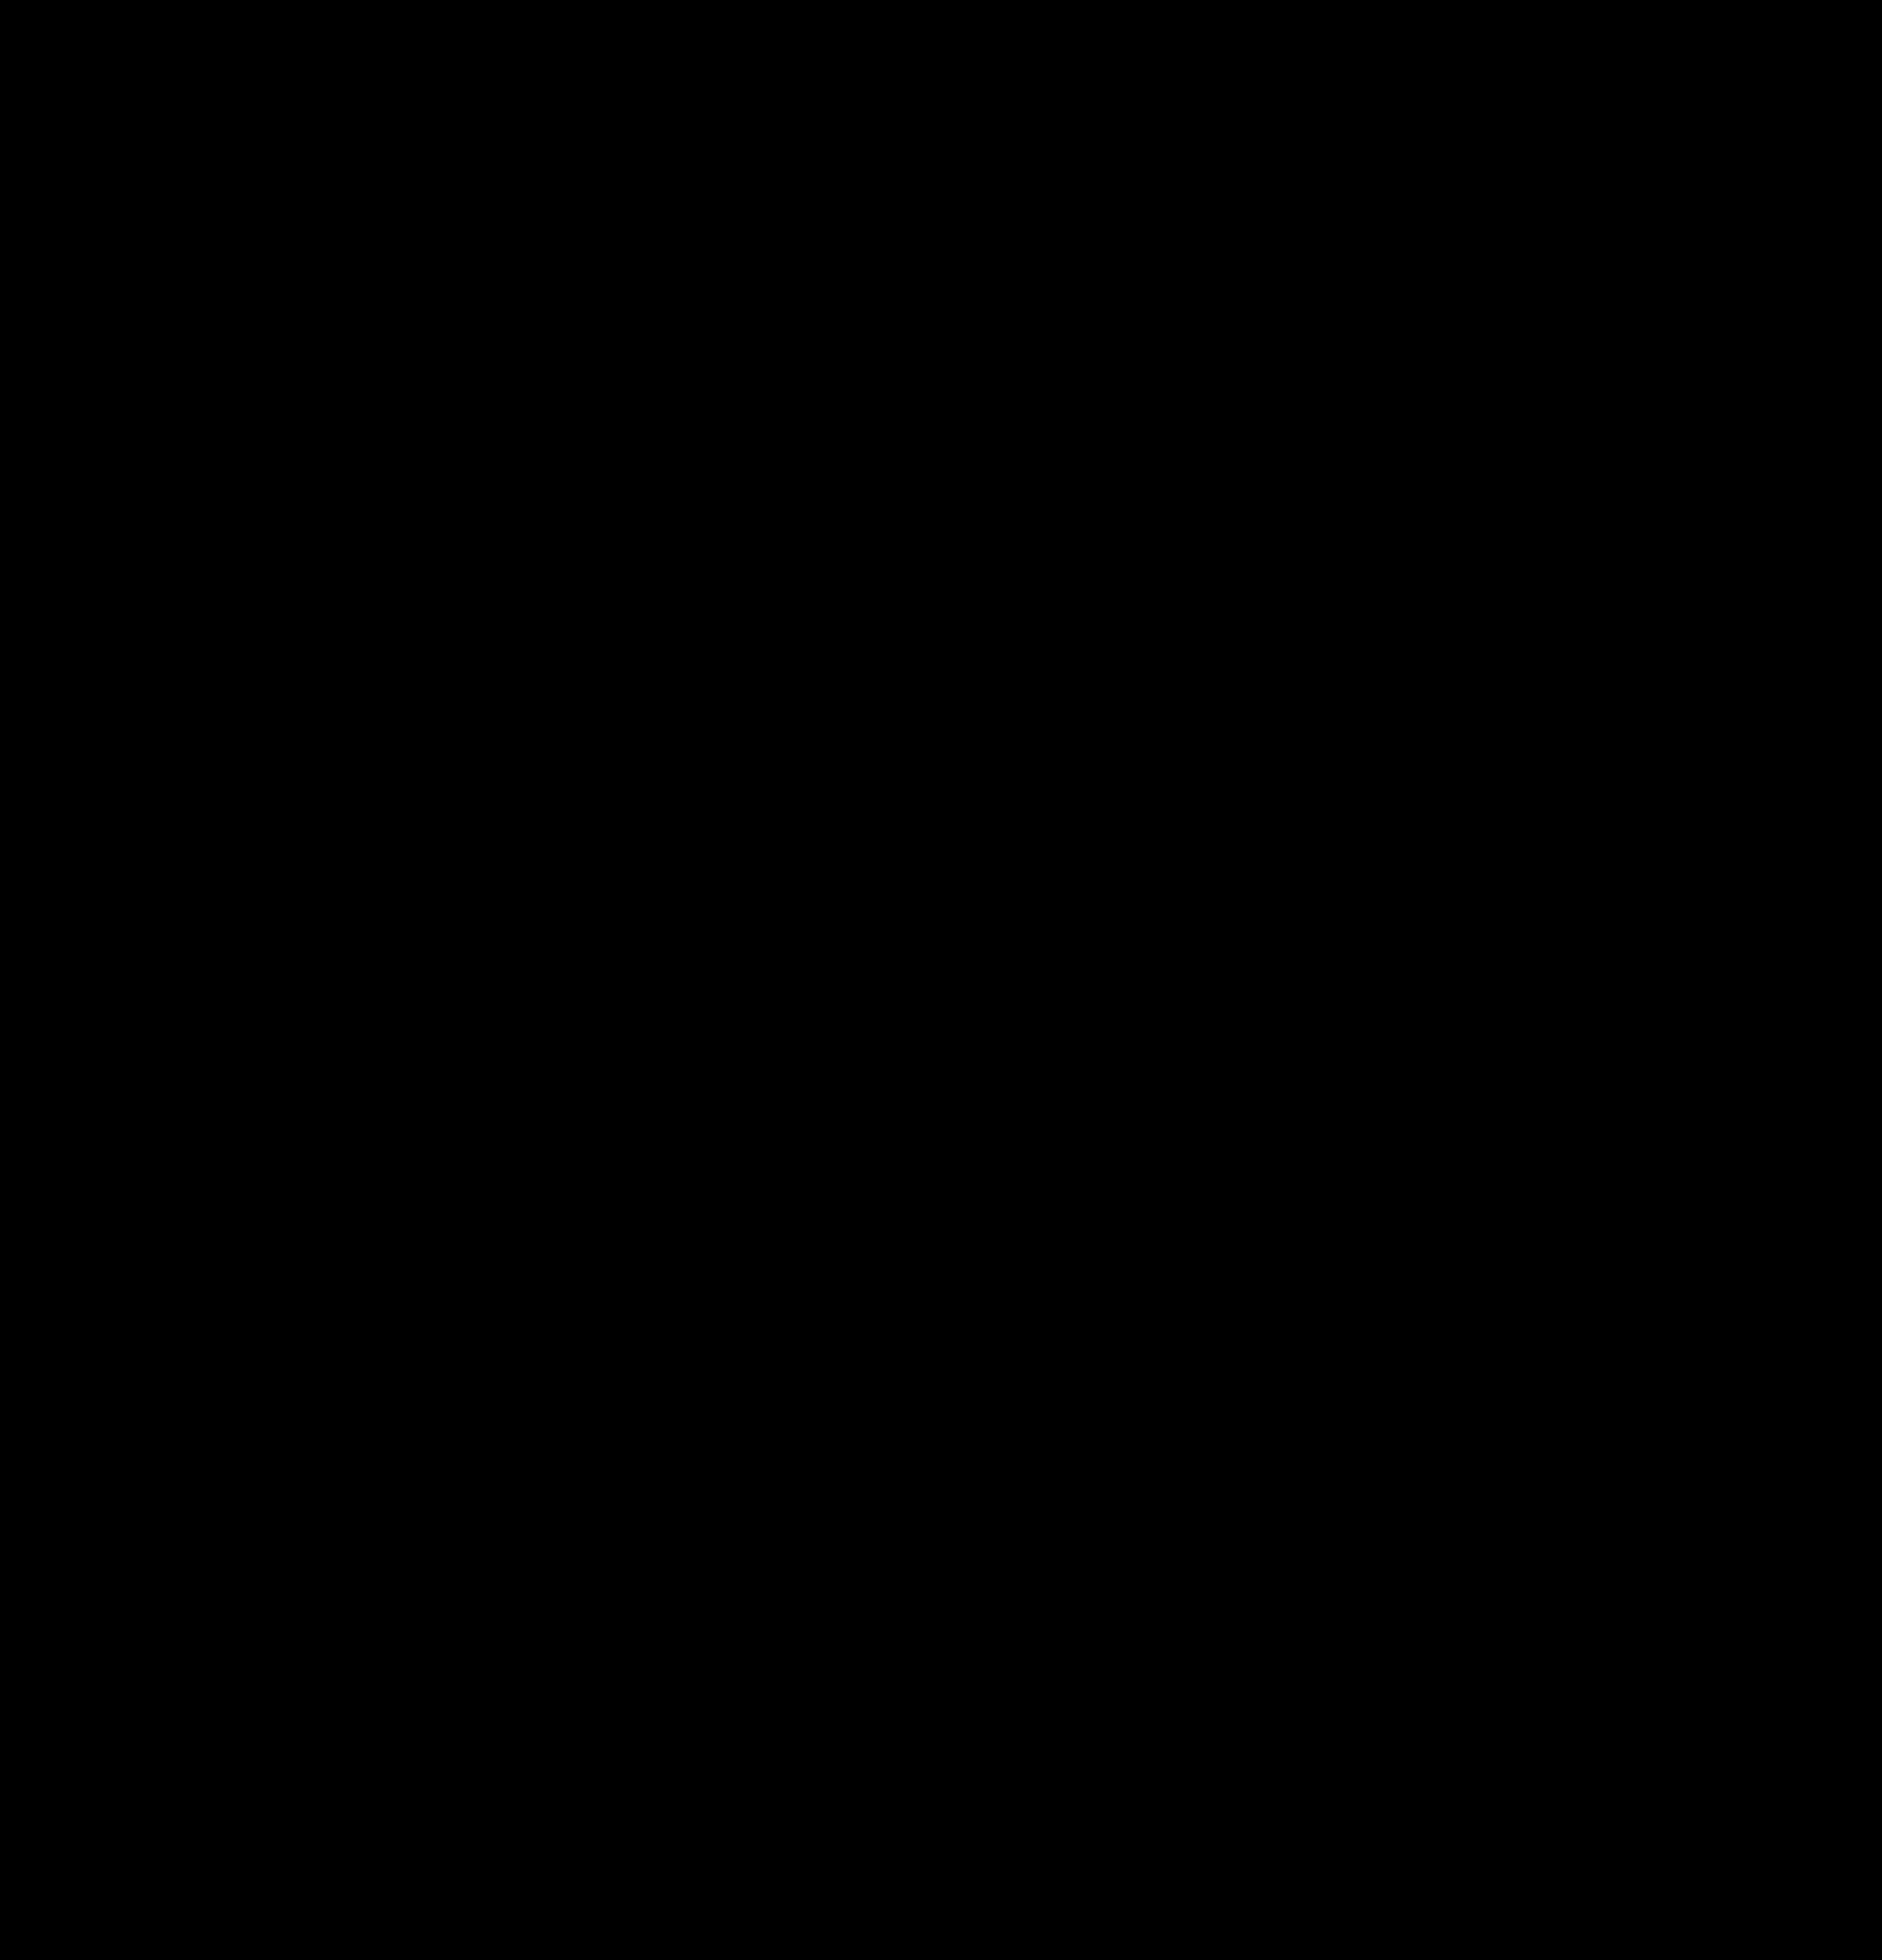

In [10]:
map = visualization.show_raster_map(
    output_file,
    cmap="inferno"
)
map

## 4. Collect and prepare Meteorological Data
Meteorological data is the only data that is not collected from CDSE using the openEO interface. Instead it come from the [Copernicus Climate Data Store](https://cds.climate.copernicus.eu/) and [Atmosphere Data Store](https://cds.climate.copernicus.eu/). To access data from these two sources you need an API key as described in the documentation:
* [CDS User Guide](https://cds.climate.copernicus.eu/how-to-api) 

Once you create the keys save them in ```key.adsapirc``` and ```key.cdsapirc``` files, looking like the examples below, and upload to `./mystorage` if running on CDSE Jupyterhub:

``` bash
key.adsapirc
url: https://ads.atmosphere.copernicus.eu/api
key: <api_key>
```
and
```` bash
key.cdsapirc
url: https://cds.climate.copernicus.eu/api
key: <api_key>
````

The cell below downloads the data, performs DEM-based corrections to some parameters and resamples to Sentinel-2 grid.

In [12]:
template_file = list(date_data_dir.glob("*_LAI.tif"))[0]
for lst_file in date_data_dir.glob("*_LST.tif"):
    sentinel3_acq_datetime_str = re.search("_(\d{8}T\d{6})_", lst_file.stem).group(1)
    sentinel3_acq_datetime = datetime.strptime(sentinel3_acq_datetime_str, "%Y%m%dT%H%M%S")
    meteo_output_path = get_meteo_data(
        datetime = sentinel3_acq_datetime,
        bbox = bbox,
        dem_path = aoi_data_dir / "cdem_300.tif",
        template_path = template_file,
        data_dir=lst_file.parent,
        cds_credentials_file=".cdsapirc",
        ads_credentials_file=".adsapirc",
    )

2026-03-11 15:25:47,348 [INFO] Process era5 for single date'.


Querying products for extent [-23.292634648088505, 24.346620828677136, -25.72921387913414, 26.764335525047954]
..and dates 2023-05-08 07:36:00 to 2023-05-10 07:36:00
Saving into mystorage/botswana/20230509/20230509_era5.grib


2026-03-11 15:27:03,858 [INFO] Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-03-11/991533a4b3000149c72ec51645eec6d.grib


Saved to file mystorage/botswana/20230509/20230509_era5.grib


2026-03-11 15:27:26,537 [INFO] Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-03-11/1070a2c8b6de6bd044669f2d0b7179ff.grib


...

2026-03-11 15:27:31,052 [INFO] Processing completed successfully.
2026-03-11 15:27:31,053 [INFO] Starting resample_to_template...
2026-03-11 15:27:31,205 [INFO] Processing completed successfully.
2026-03-11 15:27:31,206 [INFO] Starting resample_to_template...


Saving LW-IN to mystorage/botswana/20230509/20230509T073600_LW-IN.tif
Saving ETr to mystorage/botswana/20230509/20230509_ETR.tif


2026-03-11 15:27:31,359 [INFO] Processing completed successfully.
2026-03-11 15:27:31,360 [INFO] Starting resample_to_template...
2026-03-11 15:27:31,508 [INFO] Processing completed successfully.
2026-03-11 15:27:31,509 [INFO] Summing irradiance components.


Saving SW-IN-DD to mystorage/botswana/20230509/20230509_SW-IN-DD.tif


2026-03-11 15:27:31,591 [INFO] Starting resample_to_template...
2026-03-11 15:27:31,751 [INFO] Processing completed successfully.
2026-03-11 15:27:31,751 [INFO] Final output saved to: mystorage/botswana/20230509/20230509T073600_SW-IN.tif
